##### MULTIPLE LINEAR REGRESSION 

Multiple linear regression = more than one X predicting Y

In [1]:
#Step 1 importing and loading all the libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
#step: loading the dataset 
startup = pd.read_csv('50_Startups.csv')

In [4]:
#step 3: performing EDA
startup

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [5]:
startup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
startup.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [7]:
startup.duplicated().sum()

np.int64(0)

In [8]:
startup.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [9]:
#step 4: Defining X and Y 

y = startup['Profit']
X = startup.drop('Profit', axis=1)

In [10]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [11]:
X

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


In [13]:
startup['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [12]:
#Handling the categorical data 
X = pd.get_dummies(X, drop_first=True)

In [14]:
X

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [15]:
X = X.astype(int)

In [16]:
X

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349,136897,471784,0,1
1,162597,151377,443898,0,0
2,153441,101145,407934,1,0
3,144372,118671,383199,0,1
4,142107,91391,366168,1,0
5,131876,99814,362861,0,1
6,134615,147198,127716,0,0
7,130298,145530,323876,1,0
8,120542,148718,311613,0,1
9,123334,108679,304981,0,0


In [17]:
#Splitting the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

linear Regression
Y = b0 + b1x1

multiple linear regression 
y = b0 + b1x1 + b2x2 + b3x3 + bxnx

In [18]:
#Train the model 

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
#prediction 
y_pred = model.predict(X_test)

In [20]:
#evaluate 
from sklearn.metrics import r2_score, root_mean_squared_error

print("r2_score: ", r2_score(y_test, y_pred))
print("RSME: ", root_mean_squared_error(y_test, y_pred))

r2_score:  0.8987245306217987
RSME:  9056.051698304873


Profit = b0 + b1(R&D) + B2(Admin) + b3(marketing) + b4(state_florida) +b5(state_New_york)

In [21]:
coeff_startup = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeff_startup

,Feature,Coefficient
0,R&D Spend,0.805629
1,Administration,-0.068789
2,Marketing Spend,0.029856
3,State_Florida,938.749685
4,State_New York,6.909179


In [22]:
y_test

13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
Name: Profit, dtype: float64

In [23]:
y_pred

array([126362.93252171,  84608.52579874,  99677.45007307,  46357.54709785,
       128750.69322711,  50912.79650819, 109741.00850976, 100643.01925189,
        97598.94761148, 113097.03975177])

In [21]:
intercept = model.intercept_
intercept

np.float64(54028.60833339018)

Text(0.5, 1.0, 'Actual vs Predicted Profit')

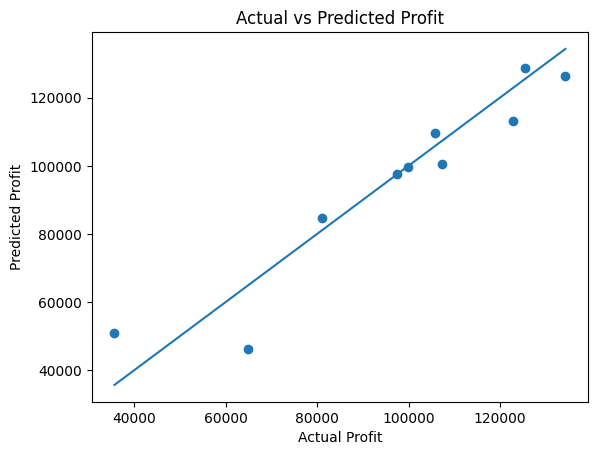

In [24]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(),y_test.max()])
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

In [25]:
X.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida',
       'State_New York'],
      dtype='object')

In [28]:
new_startup = pd.DataFrame({'R&D Spend':[150000], 'Administration':[120000], 'Marketing Spend':[300000], 'State_Florida':[1], 'State_New York':[0]})

In [29]:
prediction = model.predict(new_startup)
prediction

array([176513.76891809])